   cap-diameter  cap-shape  gill-attachment  gill-color  stem-height  \
0          1372          2                2          10     3.807467   
1          1461          2                2          10     3.807467   
2          1371          2                2          10     3.612496   
3          1261          6                2          10     3.787572   
4          1305          6                2          10     3.711971   

   stem-width  stem-color    season  class  
0        1545          11  1.804273      1  
1        1557          11  1.804273      1  
2        1566          11  1.804273      1  
3        1566          11  1.804273      1  
4        1464          11  0.943195      1  
Epoch [10/10], Loss: 0.6985, Accuracy: 50.44%
Test Loss: 0.6982
Test Accuracy: 50.78%
              precision    recall  f1-score   support

     Class 0       0.47      0.58      0.52      4909
     Class 1       0.56      0.44      0.50      5898

    accuracy                           0.51    

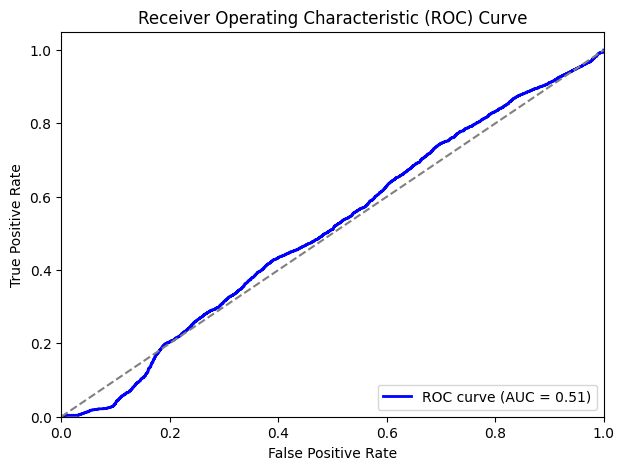

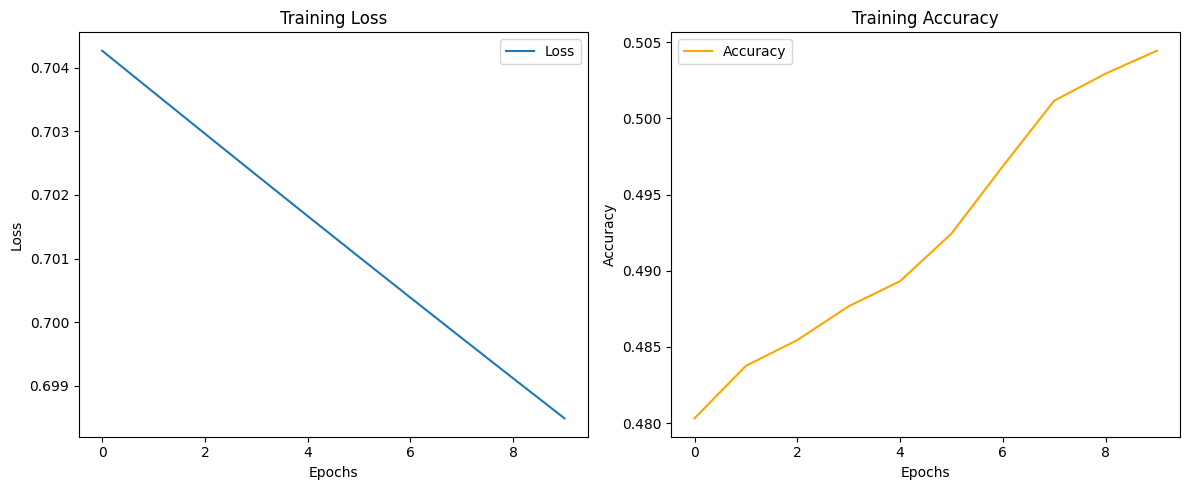

In [6]:
import torch  
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset locally
csv_path = './variant1-mushrooms.csv'  # Path to the dataset in your local directory
data = pd.read_csv(csv_path)

# Check the first few rows to ensure proper loading
print(data.head())

# Assuming the dataset contains a 'Class' column for the target
# Separate features and target
X = data.drop(columns=['class']).values  # Drop only 'Class' column for features
y = data['class'].values  # Extract the target column

# Standardize the feature values for better training performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)  # Training features as a tensor
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Training labels as a tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)  # Testing features as a tensor
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)  # Testing labels as a tensor

# Define a simple Multi-Layer Perceptron (MLP) for binary classification
class BinaryClassificationMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BinaryClassificationMLP, self).__init__()
        self.hidden_layer = nn.Linear(input_size, hidden_size)  # First layer (input to hidden)
        self.output_layer = nn.Linear(hidden_size, output_size)  # Second layer (hidden to output)
        self.relu = nn.ReLU()  # ReLU activation function for hidden layer
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation for output layer

    def forward(self, x):
        x = self.hidden_layer(x)  # Linear transformation for the hidden layer
        x = self.relu(x)  # Apply ReLU activation
        x = self.output_layer(x)  # Linear transformation for the output layer
        x = self.sigmoid(x)  # Apply sigmoid activation for binary classification
        return x

# Set hyperparameters
input_size = X_train.shape[1]  # Number of features in the dataset
hidden_size = 8  # Number of neurons in the hidden layer
output_size = 1  # Binary classification output
learning_rate = 0.001  # Learning rate for the optimizer
num_epochs = 10  # Number of epochs to train the model

# Initialize the model, loss function, and optimizer
model = BinaryClassificationMLP(input_size, hidden_size, output_size)  # Create the model instance
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # Adam optimizer

# Metrics and logging
losses = []
accuracies = []

# Training loop
model.train()  # Set the model to training mode
for epoch in range(num_epochs):
    # Forward pass: compute predictions
    outputs = model(X_train_tensor)
    
    # Compute the loss between predictions and actual labels
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())
    
    # Convert predictions to binary values (0 or 1)
    predictions = (outputs.detach().numpy() > 0.5).astype(int)
    y_train_numpy = y_train_tensor.numpy()
    accuracy = accuracy_score(y_train_numpy, predictions)
    accuracies.append(accuracy)
    
    # Backward pass: compute gradients and update weights
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()  # Compute gradients
    optimizer.step()  # Update weights based on gradients
    
    # Print loss and accuracy every 100 epochs for monitoring
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy * 100:.2f}%')

# Evaluate the model on the test dataset
model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient computation for evaluation
    outputs = model(X_test_tensor)  # Compute predictions
    test_loss = criterion(outputs, y_test_tensor)  # Compute the loss for the test set
    # Convert predictions to binary values (0 or 1)
    test_predictions = (outputs.numpy() > 0.5).astype(int)
    y_test_numpy = y_test_tensor.numpy()
    # Compute metrics
    test_accuracy = accuracy_score(y_test_numpy, test_predictions)
    print(f'Test Loss: {test_loss.item():.4f}')
    print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
    # Generate a classification report
    print(classification_report(y_test_numpy, test_predictions, target_names=["Class 0", "Class 1"]))
    # Compute ROC curve and AUC
    y_probabilities = outputs.numpy()  # Get predicted probabilities
    fpr, tpr, _ = roc_curve(y_test_numpy, y_probabilities)
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random guess)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()

# Plot loss and accuracy curves
plt.figure(figsize=(12, 5))
# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), losses, label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
# Plot training accuracy
plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), accuracies, label='Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import numpy as np

# Features and target
X = data.drop(columns=['class'])
y = data['class']

# Фільтрація важливості
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X, y)
scores = selector.scores_

# Вивід результатів
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': scores})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print(feature_scores)

           Feature     Score
5       stem-width  0.071318
6       stem-color  0.051703
4      stem-height  0.041863
1        cap-shape  0.031838
0     cap-diameter  0.027353
3       gill-color  0.023755
2  gill-attachment  0.016902
7           season  0.009340


In [20]:
# Припускаємо, що y вже є (цільовий вектор)
class_counts = pd.Series(y).value_counts().sort_index()

neg_count = class_counts[0]
pos_count = class_counts[1]

print(f'Кількість класу 0 (негативний): {neg_count}')
print(f'Кількість класу 1 (позитивний): {pos_count}')

# Вага для позитивного класу
pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32)

print(f'pos_weight (для BCEWithLogitsLoss): {pos_weight.item():.2f}')


Кількість класу 0 (негативний): 24360
Кількість класу 1 (позитивний): 29675
pos_weight (для BCEWithLogitsLoss): 0.82


Epoch [1/50], Loss: 0.6868, Accuracy: 54.49%
Epoch [10/50], Loss: 0.6649, Accuracy: 62.00%
Epoch [20/50], Loss: 0.6478, Accuracy: 63.03%
Epoch [30/50], Loss: 0.6356, Accuracy: 64.09%
Epoch [40/50], Loss: 0.6257, Accuracy: 65.32%
Epoch [50/50], Loss: 0.6179, Accuracy: 65.99%

Test Loss: 0.6055
Test Accuracy: 67.48%
              precision    recall  f1-score   support

     Class 0       0.65      0.61      0.63      4909
     Class 1       0.69      0.73      0.71      5898

    accuracy                           0.67     10807
   macro avg       0.67      0.67      0.67     10807
weighted avg       0.67      0.67      0.67     10807



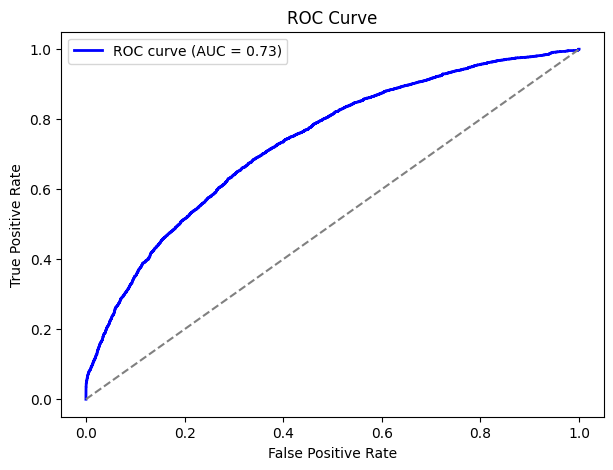

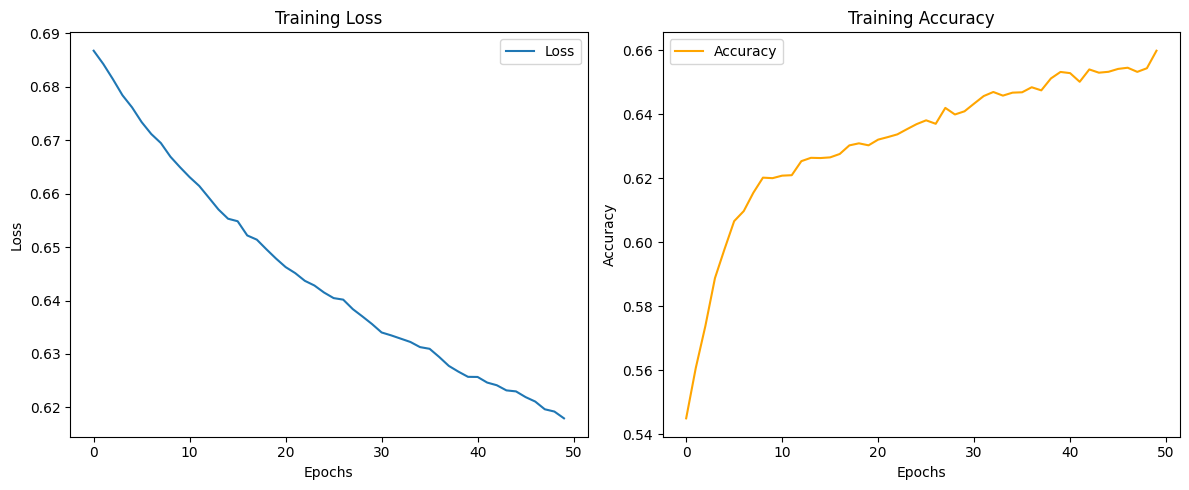

In [21]:
X = data.drop(columns=['class']).values
y = data['class'].values

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Improved MLP
class BetterMLP(nn.Module):
    def __init__(self, input_size):
        super(BetterMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)  # No sigmoid here!
        )

    def forward(self, x):
        return self.model(x)

# Hyperparams
input_size = X_train.shape[1]
model = BetterMLP(input_size)
criterion = nn.BCEWithLogitsLoss()  # More stable than BCELoss
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

# Training
losses = []
accuracies = []

model.train()
for epoch in range(num_epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    preds = torch.sigmoid(outputs).detach().numpy() > 0.5
    acc = accuracy_score(y_train, preds)
    accuracies.append(acc)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {acc * 100:.2f}%')

# Evaluation
model.eval()
with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits)
    loss_test = criterion(logits, y_test_tensor)
    preds_test = (probs.numpy() > 0.5).astype(int)
    acc_test = accuracy_score(y_test, preds_test)

    print(f'\nTest Loss: {loss_test.item():.4f}')
    print(f'Test Accuracy: {acc_test * 100:.2f}%')
    print(classification_report(y_test, preds_test, target_names=["Class 0", "Class 1"]))

    # ROC
    fpr, tpr, _ = roc_curve(y_test, probs.numpy())
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

# Loss & Accuracy Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses, label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


Epoch [10/100], Loss: 0.5737, Accuracy: 66.82%
Epoch [20/100], Loss: 0.5095, Accuracy: 70.57%
Epoch [30/100], Loss: 0.4473, Accuracy: 75.79%
Epoch [40/100], Loss: 0.3812, Accuracy: 79.93%
Epoch [50/100], Loss: 0.3329, Accuracy: 82.91%
Epoch [60/100], Loss: 0.2885, Accuracy: 85.57%
Epoch [70/100], Loss: 0.2563, Accuracy: 87.21%
Epoch [80/100], Loss: 0.2281, Accuracy: 88.83%
Epoch [90/100], Loss: 0.2073, Accuracy: 89.96%
Epoch [100/100], Loss: 0.1877, Accuracy: 90.97%

Test Loss: 0.1130
Test Accuracy: 95.45%
              precision    recall  f1-score   support

     Class 0       0.95      0.95      0.95      4909
     Class 1       0.96      0.96      0.96      5898

    accuracy                           0.95     10807
   macro avg       0.95      0.95      0.95     10807
weighted avg       0.95      0.95      0.95     10807



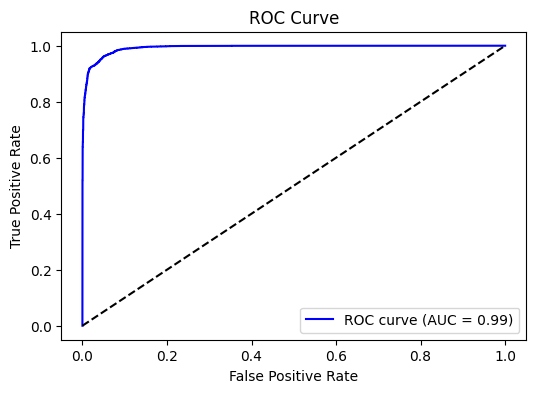

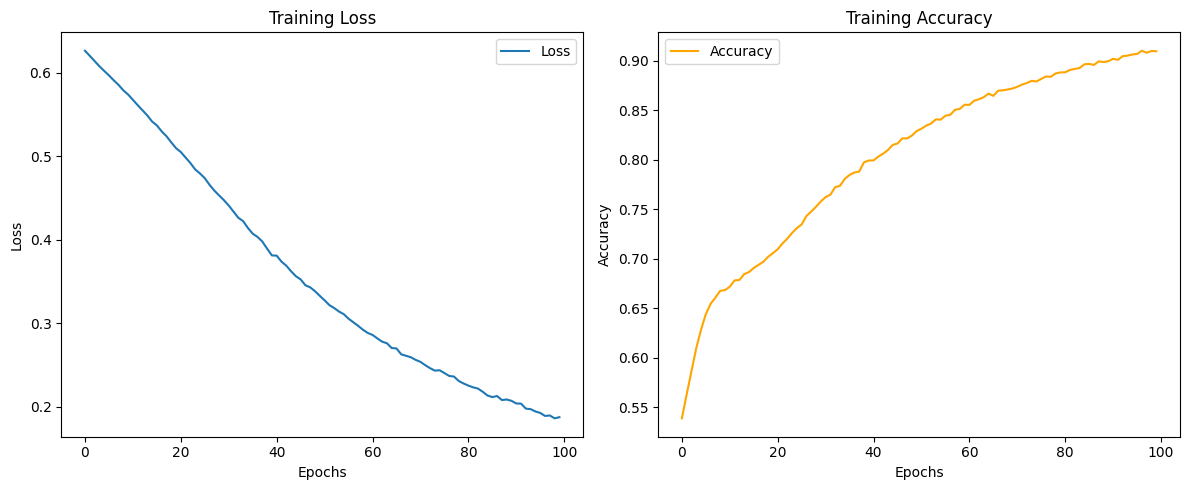

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from collections import Counter


# Separate target and features
y = data['class'].values
categorical_cols = ['cap-shape', 'gill-attachment', 'gill-color', 'stem-color']
numeric_cols = ['cap-diameter', 'stem-height', 'stem-width', 'season']

# One-hot encoding for categorical
encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(data[categorical_cols])

# Standardize numeric columns
scaler = StandardScaler()
X_num = scaler.fit_transform(data[numeric_cols])

# Combine all features
X = np.hstack([X_num, X_cat])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Calculate class imbalance
counter = Counter(y_train)
pos_weight = torch.tensor([counter[0] / counter[1]])

# Improved MLP model
class BetterMLP(nn.Module):
    def __init__(self, input_size):
        super(BetterMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.LeakyReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

# Hyperparameters
input_size = X_train.shape[1]
learning_rate = 0.001
num_epochs = 100
weight_decay = 1e-4

# Model, loss, optimizer
model = BetterMLP(input_size)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Training
losses, accuracies = [], []
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    predictions = (torch.sigmoid(outputs) > 0.5).float()
    accuracy = accuracy_score(y_train_tensor.numpy(), predictions.numpy())
    accuracies.append(accuracy)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracy * 100:.2f}%")

# Evaluation
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    test_loss = criterion(outputs, y_test_tensor)
    test_probs = torch.sigmoid(outputs)
    test_preds = (test_probs > 0.5).float()
    test_accuracy = accuracy_score(y_test_tensor.numpy(), test_preds.numpy())

    print(f"\nTest Loss: {test_loss.item():.4f}")
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
    print(classification_report(y_test_tensor.numpy(), test_preds.numpy(), target_names=["Class 0", "Class 1"]))

    # ROC
    fpr, tpr, _ = roc_curve(y_test_tensor.numpy(), test_probs.numpy())
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", color='blue')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# Plot loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss")
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(accuracies, label="Accuracy", color='orange')
plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()



Висновки: виконуючи лабораторну роботу, у ході експериментів було протестовано три архітектури нейронної мережі для бінарної класифікації. 
100 епох:
Перша модель з одним прихованим шаром показала найгірші результати: точність 63.42%, f1-міра 0.63, що свідчить про недостатню складність для якісного навчання. Друга модель з двома прихованими шарами та Dropout продемонструвала покращення: точність зросла до 69.88%, f1-міра – до 0.70. Найкращі результати показала третя, глибша модель з трьома шарами, Batch Normalization, LeakyReLU та Dropout: точність досягла 95.29%, f1-міра – 0.95. Таким чином, збільшення кількості шарів, використання нормалізації, нелінійних активацій та регуляризації суттєво покращує якість класифікації.

10 епох:
1) точність 50.34%, f1-міра 0.50
2) точність 55.58%, f1-міра 0.56
3) точність 69.87%, f1-міра 0.70

50 епох:
1) точність 60.91%, f1-міра 0.61
2) точність 67.48%, f1-міра 0.67
3) точність 87.62%, f1-міра 0.88

100 епох:
1) точність 63.42%, f1-міра 0.63
2) точність 69.88%, f1-міра 0.70
3) точність 95.29%, f1-міра 0.95